In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os 
import src.dataset_generator as dataset_generator
import src.entropy_estimator as entropy_estimator
import src.auxiliar as aux

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

n_lines = 5
cmap = blues
colors = cmap(np.linspace(0, 1, n_lines))

In [6]:
def estimate_from_probs(domain, raws, save_name, force_balance=True, samples=10, sample_points=2500, threshold_points=25, d_low=0.001, d_high=0.05, pdf_resolution=10000, data_path='./data/'):
	# Estimate classificability numerically (Entropy around points).
	ks = np.arange(2,65, dtype=int)
	classificabilities, distances_thresholds, density_thresholds = [], [], []
	k_neighbors, k_neighbors_classificabilities = [], []
	for _ in tqdm(range(samples)):
		with np.errstate(divide='ignore', invalid='ignore'):
			x_data, y_data = dataset_generator.generate_one_dim_dataset_from_functions(raws, domain, sample_points, resolution=pdf_resolution, force_balance=force_balance)
			# Compute sensible distance thresholds for the entropy estimation
			density_th, distances_th = entropy_estimator.density_dist_space(x_data, points=threshold_points, d_low=d_low, d_high=d_high, num_workers=32)
			cs, k_cs = [], []
			for th in distances_th:
				c = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=th, num_workers=32)
				cs.append(c)
			
			for k in ks:
				c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=k, num_workers=32)
				k_cs.append(c)

			classificabilities.append(cs)
			distances_thresholds.append(distances_th)
			density_thresholds.append(density_th)
			k_neighbors.append(ks)
			k_neighbors_classificabilities.append(k_cs)

	# Export data
	os.makedirs(data_path, exist_ok=True)
	np.save(os.path.join(data_path, f'{save_name}.npy'), classificabilities)
	np.save(os.path.join(data_path, f'{save_name}_distance_thresholds.npy'), distances_thresholds)
	np.save(os.path.join(data_path, f'{save_name}_density_thresholds.npy'), density_thresholds)
	np.save(os.path.join(data_path, f'{save_name}_k_neighbors.npy'), k_neighbors)
	np.save(os.path.join(data_path, f'{save_name}_k_neighbors_classificabilities.npy'), k_neighbors_classificabilities)

In [3]:
# General parameters for simulations

samples = 25
points = np.array([250,500,1000,2500,10000])
d_low = np.array([2/p for p in points])
d_high = np.array([np.maximum(5, p * 0.05)/p for p in points])
threshold_points = np.array([np.minimum(25, np.round(y*p) - np.round(x*p)).astype(int)  for x, y, p in zip(d_low, d_high, points)])

# Examples definition

examples_raws, examples_domains, examples_paths, true_classificabilities = [], [], [], []

x = np.arange(0,1,0.0001)
raw_1 = lambda x : 1 - x
raw_2 = lambda x : x
raws = [raw_1, raw_2]
examples_raws.append(raws)
examples_domains.append(x)
examples_paths.append('./data/example_3')
true_classificabilities.append(3/4)

x = np.arange(0,1,0.0001)
raw_1 = lambda x : np.where(x > 0.5, 4*(1-x), 4*x)
raw_2 = lambda x : 2*x
raws = [raw_1, raw_2]
examples_raws.append(raws)
examples_domains.append(x)
examples_paths.append('./data/example_5')
true_classificabilities.append(2/3)

x = np.arange(-4,4,0.0001)
raw_1 = lambda x : (1/np.sqrt(2*np.pi)) * np.exp( -0.5*(x - 1)**2 )
raw_2 = lambda x : (1/np.sqrt(2*np.pi)) * np.exp( -0.5*(x + 1)**2 )
raws = [raw_1, raw_2]
examples_raws.append(raws)
examples_domains.append(x)
examples_paths.append('./data/example_6')
true_classificabilities.append(0.841)

In [8]:
for raws, x, exp_path in zip(examples_raws, examples_domains, examples_paths):
	domain = [np.min(x), np.max(x)]
	for p, l, h, th in zip(points, d_low, d_high, threshold_points):
		estimate_from_probs(domain, raws, f'p_{p}', sample_points=p, samples=samples, d_low=l, d_high=h, threshold_points=th, force_balance=True, data_path=exp_path)

100%|██████████| 25/25 [04:26<00:00, 10.65s/it]


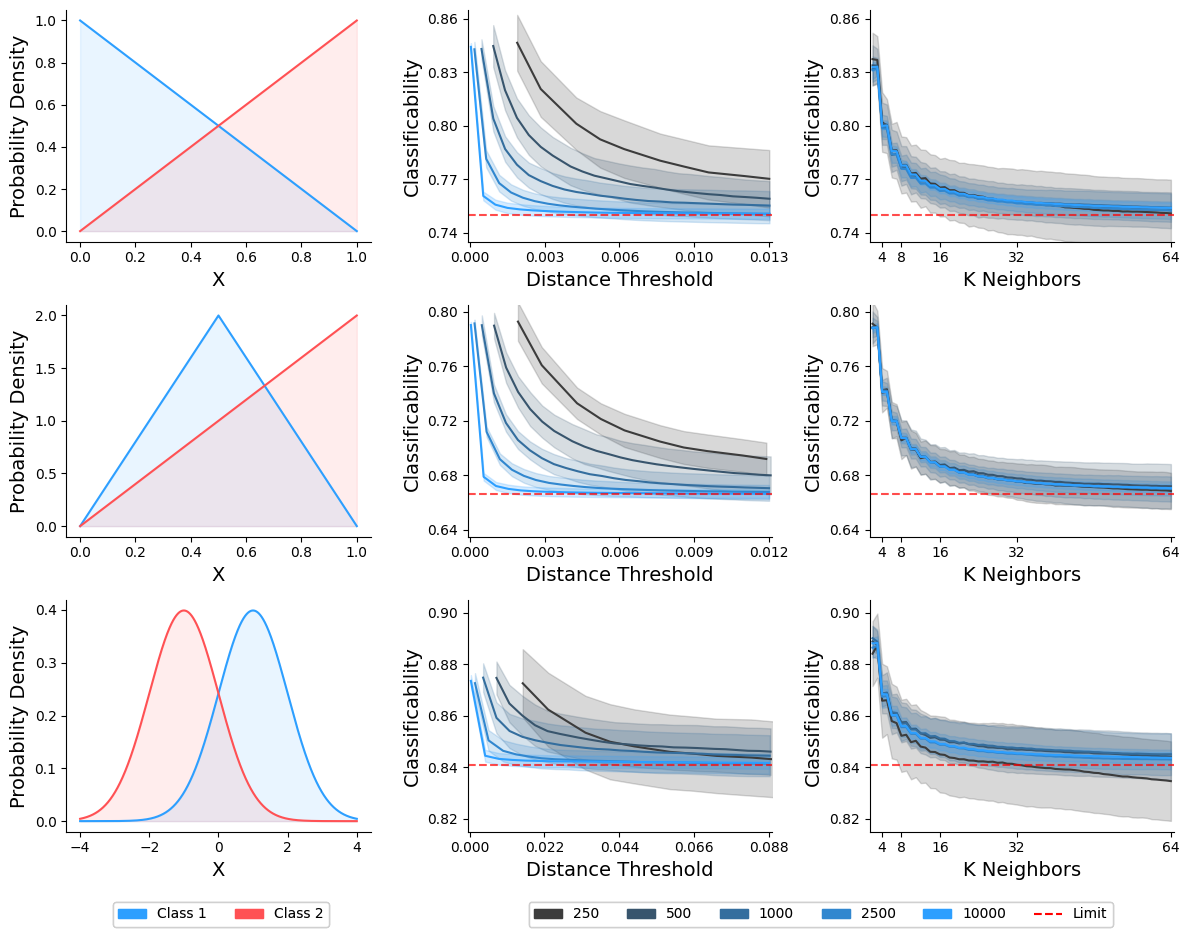

In [5]:
fig, ax = plt.subplots(3,len(examples_paths), figsize=(12,3*len(examples_paths)))

for idx, (path, raws, x, true_classificability) in enumerate(zip(examples_paths, examples_raws, examples_domains, true_classificabilities)):

	colors = cmap(np.linspace(0, 1, n_lines))
	for i, p in enumerate(points):
		clas, dist, den = np.load(os.path.join(path, f'p_{p}.npy')), np.load(os.path.join(path, f'p_{p}_distance_thresholds.npy')), np.load(os.path.join(path, f'p_{p}_density_thresholds.npy'))
		k_clas, k_dist =  np.load(os.path.join(path, f'p_{p}_k_neighbors_classificabilities.npy')), np.load(os.path.join(path, f'p_{p}_k_neighbors.npy'))


		x_den, x_dist, mean, std = np.mean(den, axis=0), np.mean(dist, axis=0), np.mean(clas, axis=0), np.std(clas, axis=0, ddof=1)
		k_dist, k_mean, k_std =  np.mean(k_dist, axis=0), np.mean(k_clas, axis=0), np.std(k_clas, axis=0, ddof=1)

		ax[idx,1].plot(x_dist, mean, color=colors[i])
		ax[idx,1].fill_between(x_dist, mean + std, mean - std, alpha=0.2, color=colors[i], label=f'{p}')	
		#aux_ax = ax[1,idx].twiny()
		#aux_ax.set_xticks(x_dist, x_den)
		ax[idx,1].set_xticks( np.linspace(0, x_dist[-1], 5), [f'{x:.3f}' for x in np.linspace(0, x_dist[-1], 5)])

		ax[idx,2].plot(k_dist, k_mean, color=colors[i])
		ax[idx,2].fill_between(k_dist, k_mean + k_std, k_mean - k_std, alpha=0.2, color=colors[i], label=f'{p}')	
		ax[idx,2].set_xticks([4,8,16,32,64])

	ax[idx,1].set_ylabel('Classificability')
	ax[idx,1].set_xlabel('Distance Threshold')

	
	ax[idx,2].set_ylabel('Classificability')
	ax[idx,2].set_xlabel('K Neighbors')

	x_delta = (np.max(x_dist) - np.min(x_dist)) * 0.01
	ax[idx,1].set_xlim(np.min(x_dist)-x_delta, np.max(x_dist)+x_delta)
	ax[idx,1].plot([np.min(x_dist)-x_delta, np.max(x_dist)+x_delta], [true_classificability, true_classificability], 'r--', alpha=0.7, label='Limit')


	x_delta = (np.max(k_dist) - np.min(k_dist)) * 0.01
	ax[idx,2].set_xlim(np.min(k_dist)-x_delta, np.max(k_dist)+x_delta)
	ax[idx,2].plot([np.min(k_dist)-x_delta, np.max(k_dist)+x_delta], [true_classificability, true_classificability], 'r--', alpha=0.7, label='Limit')

	colors = ['#2D9FFF', '#FF5154']
	num_classes = len(raws)
	max_opt_y = 0
	for i in range(num_classes):
		ax[idx,0].fill_between(x, 0, raws[i](x), color=colors[i] if colors is not None else None, alpha=0.1, label=f'Class {i+1}')
		ax[idx,0].plot(x, raws[i](x), color=colors[i] if colors is not None else None)
		max_opt_y = np.max(raws[i](x)) if np.max(raws[i](x)) > 0 else max_opt_y
	ax[idx,0].set_ylabel('Probability Density')
	ax[idx,0].set_xlabel('X')

	for j in range(3):
		ax[idx,j].spines['top'].set_visible(False)
		ax[idx,j].spines['right'].set_visible(False)

	handles, labels = ax[idx,1].get_legend_handles_labels()
	legend = fig.legend(handles, labels, loc='upper center', ncol=len(points)+1, bbox_to_anchor=(4/6+0.0215, 0))
	for handle in legend.legend_handles:
		handle.set_alpha(1.0)

	handles, labels = ax[idx,0].get_legend_handles_labels()
	legend = fig.legend(handles, labels, loc='upper center', ncol=num_classes, bbox_to_anchor=(1/6+0.0215, 0))
	for handle in legend.legend_handles:
		handle.set_alpha(1.0)

	ax[0,1].set_yticks([0.74,0.77,0.8,0.83,0.86])
	ax[0,1].set_ylim([0.735,0.865])
	ax[0,2].set_yticks([0.74,0.77,0.8,0.83,0.86])
	ax[0,2].set_ylim([0.735,0.865])
	ax[1,1].set_yticks([0.64,0.68,0.72,0.76,0.80])
	ax[1,1].set_ylim([0.635,0.805])
	ax[1,2].set_yticks([0.64,0.68,0.72,0.76,0.80])
	ax[1,2].set_ylim([0.635,0.805])
	ax[2,1].set_yticks([0.82,0.84,0.86,0.88,0.90])
	ax[2,1].set_ylim([0.815,0.905])
	ax[2,2].set_yticks([0.82,0.84,0.86,0.88,0.90])
	ax[2,2].set_ylim([0.815,0.905])

#title = fig.suptitle('Effect of finite size datasets on the estimation', fontsize=16, y=1, x=0.5)
plt.tight_layout()
plt.savefig('./images/classificability_examples_size.png', dpi=300, bbox_extra_artists=(legend,), bbox_inches='tight')
plt.show()

